# Notebook 01: Data Exploration & Validation

## Objective
This notebook focuses on understanding and validating all datasets used in the
AI-Assisted Automated Recruitment System (ATS).

Goals:
- Explore resume, job description, and resume–JD pair datasets
- Understand text length, structure, and quality
- Identify usable text columns for ML
- Compare basic patterns between human-written and AI-generated resumes

⚠️ No ML models are trained in this notebook.
⚠️ This notebook is only for data understanding and validation.

Next notebooks will use insights from here for:
- AI-generated resume detection
- Resume–JD matching
- Ranking and pattern discovery


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
import re

pd.set_option("display.max_colwidth", 200)


In [54]:
Dataset1 = pd.read_csv("AI Generated Essays Dataset.csv")
Dataset1

,text,generated
0,"Machine learning, a subset of artificial intelligence, has rapidly emerged as a transformative force, revolutionizing industries and redefining the possibilities of technology. At its core, machin...",1
1,"A decision tree, a prominent machine learning algorithm, structures decision-making in a tree-like model. Nodes represent decisions, branches signify outcomes, and leaves denote final decisions or...",1
2,"Education, a cornerstone of societal progress, extends beyond the classroom, shaping individuals and fostering the development of nations. It encompasses formal and informal learning, equipping in...",1
3,"Computers, the backbone of modern technology, have revolutionized every facet of human life. From personal computing devices to massive data centers, computers drive innovation, automation, and co...",1
4,"Chess, a timeless game of strategy and intellect, transcends cultural and geographical boundaries, captivating minds for centuries. The 64-square battlefield and distinct movements of each piece c...",1
...,...,...
1455,"There has been a fuss about the Elector College. Many people get confused about how it works and if they're satisfied with the whole process. Show we ""abolish"" the Elector College? Should we keep ...",0
1456,Limiting car usage has many advantages. Such as putting a lot less pollution in the air and having your stress level go down letting you spend time with your family and friends. When we put pollut...,0
1457,"There's a new trend that has been developing for years now, and soon will be in full throttle affect. The mass amount of pollution being produced worldwide over the years has been at terrifying le...",0
1458,As we all know cars are a big part of our society today. However cars have a bigger impact than we think. Some people can't live without there car. Some people can go their whole life without a ca...,0


Columns

text → essay text

generated → label

0 = human written

1 = AI generated

In [56]:
Dataset1.head()

,text,generated
0,"Machine learning, a subset of artificial intelligence, has rapidly emerged as a transformative force, revolutionizing industries and redefining the possibilities of technology. At its core, machin...",1
1,"A decision tree, a prominent machine learning algorithm, structures decision-making in a tree-like model. Nodes represent decisions, branches signify outcomes, and leaves denote final decisions or...",1
2,"Education, a cornerstone of societal progress, extends beyond the classroom, shaping individuals and fostering the development of nations. It encompasses formal and informal learning, equipping in...",1
3,"Computers, the backbone of modern technology, have revolutionized every facet of human life. From personal computing devices to massive data centers, computers drive innovation, automation, and co...",1
4,"Chess, a timeless game of strategy and intellect, transcends cultural and geographical boundaries, captivating minds for centuries. The 64-square battlefield and distinct movements of each piece c...",1


In [58]:
Dataset1.tail()

,text,generated
1455,"There has been a fuss about the Elector College. Many people get confused about how it works and if they're satisfied with the whole process. Show we ""abolish"" the Elector College? Should we keep ...",0
1456,Limiting car usage has many advantages. Such as putting a lot less pollution in the air and having your stress level go down letting you spend time with your family and friends. When we put pollut...,0
1457,"There's a new trend that has been developing for years now, and soon will be in full throttle affect. The mass amount of pollution being produced worldwide over the years has been at terrifying le...",0
1458,As we all know cars are a big part of our society today. However cars have a bigger impact than we think. Some people can't live without there car. Some people can go their whole life without a ca...,0
1459,"Cars have been around since the 1800's and have been popular ever since. Although, in recent years the number of cars bought and licenses attained have been dropping. Car usage has also dropped, w...",0


In [62]:
# Basic inspection
print("Shape of dataset:", Dataset1.shape)
print("\nColumn names:")
print(Dataset1.columns.tolist())

print("\nData types:")
print(Dataset1.dtypes)

Shape of dataset: (1460, 2)

Column names:
['text', 'generated']

Data types:
text         object
generated     int64
dtype: object


# 📊 Dataset 1 — Initial Inspection & Domain Insights

## 🔹 Dataset Shape
- The dataset contains **1,460 rows** and **2 columns**.
- Each row represents **one essay/document**.

---

## 🔹 Column Overview

| Column Name | Data Type | Description |
|------------|----------|-------------|
| `text` | object | Essay content in natural language (long-form text) |
| `generated` | int64 | Binary label indicating whether the essay is AI-generated |

---

## 🔹 Domain Analysis
- This is a **Natural Language Processing (NLP)** dataset.
- The domain is **AI-generated text detection / text classification**.
- The `text` column contains **paragraph-length essays** on diverse topics such as:
  - Machine Learning
  - Education
  - Technology
  - Chess
- The writing style appears **formal and informational**, similar to academic or explanatory essays.

---

## 🔹 Supervised vs Unsupervised Confirmation
- The presence of the `generated` column confirms this is a **supervised learning dataset**.
- `generated` acts as the **target (label)**:
  - `1` → AI-generated text  
  - `0` → Human-written text *(to be confirmed via value counts in the next step)*

---

## 🔹 Data Type Validation
- `text` is correctly stored as an **object/string**, suitable for NLP preprocessing.
- `generated` is stored as an **integer**, appropriate for binary classification models.

---

## 🔹 Early Observations (Pre-Cleaning)
- No structural issues detected at this stage.
- Dataset is **well-formed for text classification**.
- Further checks are still required for:
  - Missing values
  - Duplicate essays
  - Empty or extremely short text
  - Class imbalance

---

## ✅ Conclusion (Step 1)
- Dataset is **cleanly structured**, **labeled**, and **ready for preprocessing**.
- Safe to proceed to **data quality checks** before any text cleaning or modeling.


In [69]:
Dataset1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       1460 non-null   object
 1   generated  1460 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 22.9+ KB


In [71]:
Dataset1.describe()

,generated
count,1460.000000
mean,0.058219
std,0.234238
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [65]:
# Missing values check
print("Missing values per column:")
print(Dataset1.isnull().sum())

# Percentage of missing values
print("\nMissing values percentage:")
print((Dataset1.isnull().sum() / len(Dataset1)) * 100)

# Label distribution
print("\nLabel distribution (generated):")
print(Dataset1['generated'].value_counts())

print("\nLabel distribution (percentage):")
print(Dataset1['generated'].value_counts(normalize=True) * 100)


Missing values per column:
text         0
generated    0
dtype: int64

Missing values percentage:
text         0.0
generated    0.0
dtype: float64

Label distribution (generated):
generated
0    1375
1      85
Name: count, dtype: int64

Label distribution (percentage):
generated
0    94.178082
1     5.821918
Name: proportion, dtype: float64


# 📊 STEP 2 — Missing Values & Label Distribution Analysis

## 🔹 Missing Values Check
- No missing values were found in the dataset.
- Both columns (`text` and `generated`) have **0 null values**.

| Column | Missing Count | Missing % |
|------|---------------|-----------|
| `text` | 0 | 0.0% |
| `generated` | 0 | 0.0% |

**Insight:**  
The dataset is **complete** and does not require any missing value imputation.

---

## 🔹 Label Distribution Analysis

| Label (`generated`) | Count | Percentage |
|--------------------|-------|------------|
| `0` (Human-written) | 1,375 | 94.18% |
| `1` (AI-generated) | 85 | 5.82% |

---

## ⚠️ Class Imbalance Observation
- The dataset is **heavily imbalanced**.
- Human-written essays dominate the dataset.
- AI-generated essays form a **minority class (< 6%)**.

---

## 🔹 Implications for Modeling (Important)
- Accuracy alone will be misleading.
- Evaluation metrics such as:
  - **Precision**
  - **Recall**
  - **F1-score**
  - **ROC-AUC**
  should be prioritized.
- During modeling, techniques such as:
  - Class weighting
  - Oversampling / undersampling  
  may be required.

---

## ✅ Conclusion (Step 2)
- Dataset has **no missing values**.
- **Severe class imbalance** is present and must be handled carefully during training.
- Safe to proceed to **duplicate and text-quality analysis**.



In [74]:
# Check for exact duplicate rows
duplicate_rows = Dataset1.duplicated().sum()
print("Exact duplicate rows:", duplicate_rows)

# Check for duplicate text entries only
duplicate_texts = Dataset1.duplicated(subset=['text']).sum()
print("Duplicate texts (same essay content):", duplicate_texts)

# Show a few duplicate examples if they exist
if duplicate_texts > 0:
    print("\nSample duplicate texts:")
    display(Dataset1[Dataset1.duplicated(subset=['text'], keep=False)].head())


Exact duplicate rows: 1
Duplicate texts (same essay content): 1

Sample duplicate texts:


,text,generated
53,"""The evolution of artificial intelligence (AI) has ushered in a new era of possibilities and challenges. From machine learning algorithms to advanced robotics, AI technologies are reshaping indust...",1
54,"""The evolution of artificial intelligence (AI) has ushered in a new era of possibilities and challenges. From machine learning algorithms to advanced robotics, AI technologies are reshaping indust...",1


# 📊 STEP 3 — Duplicate Text Analysis

## 🔹 Duplicate Rows Check
- **Exact duplicate rows found:** 1
- This indicates that one row in the dataset is a complete repetition of another row.

---

## 🔹 Duplicate Essay Content Check
- **Duplicate text entries found:** 1
- Two different rows contain **identical essay content**.

### Example
- Row 53 and Row 54 contain the **same AI-generated essay**.
- Both are labeled as `generated = 1`.

---

## 🔹 Why This Matters
- Duplicate text samples can:
  - Bias the model toward repeated patterns
  - Cause data leakage between train and test splits
  - Artificially inflate performance metrics

---

## 🔹 Cleaning Decision (Recommended)
- Since the duplicate essays:
  - Have identical text
  - Have identical labels  
- One copy should be **removed during preprocessing**.

⚠️ **Note:**  
Removal will be done **after analysis**, not during inspection.

---

## ✅ Conclusion (Step 3)
- Dataset contains **minimal duplication** (only one duplicate essay).
- Safe to proceed with duplicate removal in the cleaning phase.
- Ready for **text sanity checks (length, empty text, noise)**.



In [76]:
# Shape before dropping duplicates
print("Shape before duplicate removal:", Dataset1.shape)

# Drop duplicate essays based on text
Dataset1 = Dataset1.drop_duplicates(subset=['text']).reset_index(drop=True)

# Shape after dropping duplicates
print("Shape after duplicate removal:", Dataset1.shape)

# Final duplicate check
print("\nRemaining duplicate texts:", Dataset1.duplicated(subset=['text']).sum())


Shape before duplicate removal: (1460, 2)
Shape after duplicate removal: (1459, 2)

Remaining duplicate texts: 0


# 🧹 STEP 3.1 — Duplicate Removal

## 🔹 Shape Before Cleaning
- Dataset size before duplicate removal: **1,460 rows × 2 columns**

---

## 🔹 Duplicate Removal Strategy
- Duplicates were identified based on the **`text` column**.
- This ensures that **each essay appears only once** in the dataset.
- Duplicate essays had identical labels, making removal safe.

---

## 🔹 Shape After Cleaning
- Dataset size after duplicate removal: **1,459 rows × 2 columns**
- **1 duplicate essay** was removed.

---

## 🔹 Post-Cleaning Validation
- Remaining duplicate texts: **0**
- No duplicate essay content exists in the dataset.

---

## ✅ Conclusion
- Duplicate removal was successful.
- Dataset now contains **unique essays only**.
- Safe to proceed to **text quality and length analysis** before further preprocessing.



In [80]:
# Create text length features
Dataset1['char_length'] = Dataset1['text'].astype(str).apply(len)
Dataset1['word_length'] = Dataset1['text'].astype(str).apply(lambda x: len(x.split()))

# Empty text check
empty_texts = (Dataset1['char_length'] == 0).sum()
print("Empty texts:", empty_texts)

# Very short text check (less than 20 words)
short_texts = (Dataset1['word_length'] < 20).sum()
print("Very short texts (<20 words):", short_texts)

# Basic statistics
print("\nCharacter length statistics:")
print(Dataset1['char_length'].describe())

print("\nWord length statistics:")
print(Dataset1['word_length'].describe())


Empty texts: 0
Very short texts (<20 words): 0

Character length statistics:
count    1459.000000
mean     3064.554489
std      1008.473178
min       251.000000
25%      2455.000000
50%      2910.000000
75%      3570.500000
max      8436.000000
Name: char_length, dtype: float64

Word length statistics:
count    1459.000000
mean      535.483893
std       179.111303
min        36.000000
25%       430.000000
50%       514.000000
75%       624.500000
max      1360.000000
Name: word_length, dtype: float64


# STEP 4 — Text Length & Quality Analysis

## Text Completeness
- No empty text entries were found.
- All essays contain valid textual content.

## Short Text Check
- No essays have fewer than 20 words.
- All samples contain sufficient information for NLP modeling.

## Text Length Distribution
- Essays are long-form documents.
- Average length:
  - ~3,065 characters
  - ~535 words per essay
- Minimum length is still reasonably large:
  - 251 characters
  - 36 words

## Variability
- Text length shows moderate variation.
- No extreme outliers that require removal at this stage.

## Conclusion
- Text data is high quality and consistent.
- No samples need to be dropped based on length.
- Safe to proceed to visualization and further preprocessing.



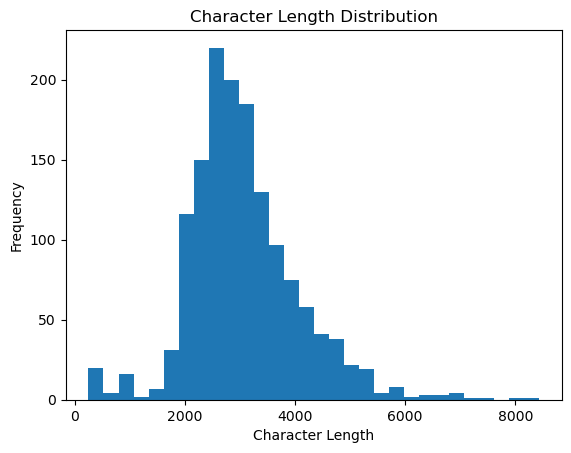

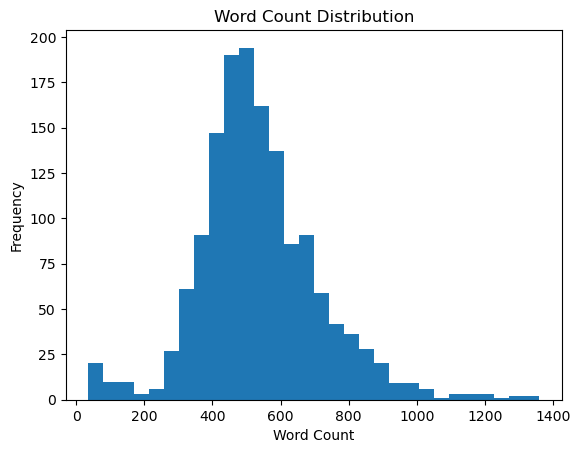

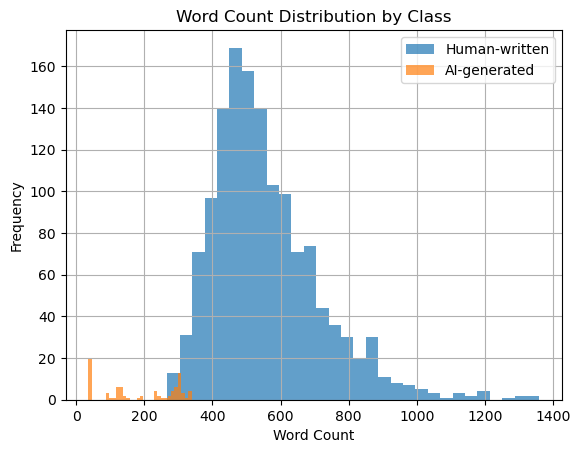

In [83]:
import matplotlib.pyplot as plt

# Character length distribution
plt.figure()
plt.hist(Dataset1['char_length'], bins=30)
plt.xlabel("Character Length")
plt.ylabel("Frequency")
plt.title("Character Length Distribution")
plt.show()

# Word length distribution
plt.figure()
plt.hist(Dataset1['word_length'], bins=30)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution")
plt.show()

# Word length by class
plt.figure()
Dataset1[Dataset1['generated'] == 0]['word_length'].hist(bins=30, alpha=0.7)
Dataset1[Dataset1['generated'] == 1]['word_length'].hist(bins=30, alpha=0.7)
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.title("Word Count Distribution by Class")
plt.legend(["Human-written", "AI-generated"])
plt.show()


# STEP 5 — Text Length Visualization Insights

## Observations
- Most essays fall within a consistent length range.
- Distributions are right-skewed, with a small number of longer essays.
- AI-generated and human-written texts show overlapping length patterns.

## Interpretation
- Text length alone is not sufficient to distinguish AI vs human content.
- Length-based filtering is not required.

## Cleaning Implication
- No truncation or length-based removal is needed.
- Dataset is suitable for uniform text preprocessing.


In [103]:
import re
import nltk
import pandas as pd

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sneha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Sneha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [105]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def full_text_cleaning(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    
    return " ".join(words)


In [107]:
Dataset1['final_clean_text'] = Dataset1['text'].apply(full_text_cleaning)

Dataset1[['text', 'final_clean_text']].head()


,text,final_clean_text
0,"Machine learning, a subset of artificial intelligence, has rapidly emerged as a transformative force, revolutionizing industries and redefining the possibilities of technology. At its core, machin...",machine learning subset artificial intelligence rapidly emerged transformative force revolutionizing industry redefining possibility technology core machine learning enables computer learn data ma...
1,"A decision tree, a prominent machine learning algorithm, structures decision-making in a tree-like model. Nodes represent decisions, branches signify outcomes, and leaves denote final decisions or...",decision tree prominent machine learning algorithm structure decision making tree like model node represent decision branch signify outcome leaf denote final decision prediction algorithm evaluate...
2,"Education, a cornerstone of societal progress, extends beyond the classroom, shaping individuals and fostering the development of nations. It encompasses formal and informal learning, equipping in...",education cornerstone societal progress extends beyond classroom shaping individual fostering development nation encompasses formal informal learning equipping individual knowledge skill critical ...
3,"Computers, the backbone of modern technology, have revolutionized every facet of human life. From personal computing devices to massive data centers, computers drive innovation, automation, and co...",computer backbone modern technology revolutionized every facet human life personal computing device massive data center computer drive innovation automation connectivity rapid advancement processi...
4,"Chess, a timeless game of strategy and intellect, transcends cultural and geographical boundaries, captivating minds for centuries. The 64-square battlefield and distinct movements of each piece c...",chess timeless game strategy intellect transcends cultural geographical boundary captivating mind century square battlefield distinct movement piece create complex tapestry possibility making ches...


In [109]:
Dataset1['clean_word_count'] = Dataset1['final_clean_text'].apply(lambda x: len(x.split()))
Dataset1[['word_length', 'clean_word_count']].head()


,word_length,clean_word_count
0,96,62
1,103,75
2,93,71
3,92,63
4,110,78


# STEP 6 — Text Preprocessing

## Operations Performed
- Converted text to lowercase.
- Removed punctuation and numerical characters.
- Normalized extra whitespace.
- Removed English stopwords.
- Applied lemmatization.
- Stored processed text in `final_clean_text`.

## Validation
- Cleaned text preserves semantic meaning.
- Noise and non-informative words are removed.
- Word count reduction is expected and justified.

## Outcome
- Dataset is fully preprocessed.
- Text is ready for feature extraction and modeling.


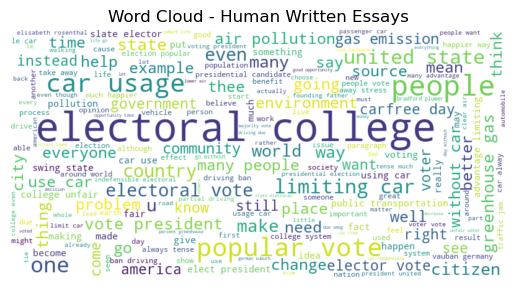

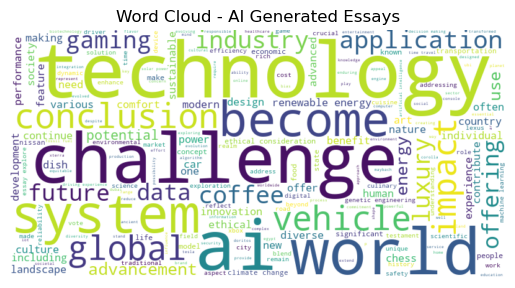

In [113]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Separate text by class
human_text = " ".join(Dataset1[Dataset1['generated'] == 0]['final_clean_text'])
ai_text = " ".join(Dataset1[Dataset1['generated'] == 1]['final_clean_text'])

# Human-written word cloud
wordcloud_human = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(human_text)

plt.figure()
plt.imshow(wordcloud_human, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - Human Written Essays")
plt.show()

# AI-generated word cloud
wordcloud_ai = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ai_text)

plt.figure()
plt.imshow(wordcloud_ai, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud - AI Generated Essays")
plt.show()


# STEP 7 — Word Cloud Analysis

## Human-Written Essays
- Dominant terms relate to social, political, and civic topics.
- Language appears opinion-driven and context-specific.
- Words reflect real-world entities, institutions, and collective perspectives.

## AI-Generated Essays
- Dominant terms are generic and topic-agnostic.
- Frequent use of abstract and explanatory vocabulary.
- Language focuses on systems, technology, and broad concepts.

## Key Observation
- Human-written text shows contextual and domain-specific diversity.
- AI-generated text shows generalized, repetitive thematic patterns.

## Conclusion
- Word clouds visually support differences in writing style.
- These patterns justify proceeding to quantitative feature extraction.


# STEP 8 — Feature Extraction (TF-IDF)

## Method
- TF-IDF vectorization was applied on cleaned text.
- Unigrams and bigrams were used.
- Vocabulary size was limited to 5,000 features.

## Output
- Text data was converted into numerical feature vectors.
- Each essay is represented by a TF-IDF weighted vector.

## Validation
- Feature names confirm meaningful vocabulary.
- TF-IDF scores highlight important words per document.

## Outcome
- Dataset is now ready for supervised model training.


In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Input and target
X = Dataset1['final_clean_text']
y = Dataset1['generated']

# TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# Fit and transform
X_tfidf = tfidf.fit_transform(X)

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (1459, 5000)


In [118]:
# Feature names (words)
feature_names = tfidf.get_feature_names_out()

# Show first 20 features
feature_names[:20]


array(['ability', 'able', 'able get', 'able see', 'able vote', 'abolish',
       'abolish electoral', 'abolished', 'abolishing',
       'abolishing electoral', 'absolutely', 'abundance', 'access',
       'accessible', 'accessible public', 'accident', 'accomplish',
       'according', 'according article', 'according bradford'],
      dtype=object)

In [120]:
import pandas as pd

# Convert first sample vector to readable form
sample_df = pd.DataFrame(
    X_tfidf[0].toarray(),
    columns=feature_names
)

# Top contributing words in first essay
sample_df.T.sort_values(by=0, ascending=False).head(10)


,0
learning,0.562994
machine,0.484326
intelligence,0.157642
privacy,0.157642
careful,0.153699
application,0.150250
data,0.148675
computer,0.145772
efficiency,0.144428
advance,0.141921


# STEP 8 — TF-IDF Vectorization Insights

## Feature Matrix
- TF-IDF matrix shape: **(1459, 5000)**
- Each row represents one essay.
- Each column represents a unique word or word pair.

## Vocabulary Validation
- Feature names include both unigrams and bigrams.
- Vocabulary terms are meaningful and domain-relevant.
- Confirms vectorization was applied on cleaned text.

## TF-IDF Weight Interpretation
- Higher TF-IDF values indicate more important words in a document.
- For the first essay, dominant terms include:
  - learning
  - machine
  - intelligence
  - data
- These words align with the essay topic, validating correct feature extraction.

## Conclusion
- Text data has been successfully transformed into numerical form.
- Feature representation preserves semantic importance.
- Dataset is now ready for supervised model training.


In [124]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest label distribution:")
print(y_test.value_counts(normalize=True) * 100)


Train shape: (1167, 5000)
Test shape: (292, 5000)

Train label distribution:
generated
0    94.258783
1     5.741217
Name: proportion, dtype: float64

Test label distribution:
generated
0    94.178082
1     5.821918
Name: proportion, dtype: float64


In [126]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))
print("Class weights:", class_weight_dict)


Class weights: {0: 0.5304545454545454, 1: 8.708955223880597}


# STEP 9 — Train–Test Split & Class Imbalance Insights

## Train–Test Split
- Dataset was split using an 80:20 ratio.
- Training set shape: (1167, 5000)
- Test set shape: (292, 5000)
- Stratified sampling preserved class proportions.

## Class Distribution Validation
- Training and test sets maintain similar label ratios.
- Majority class (`0`) ≈ 94%
- Minority class (`1`) ≈ 6%
- No distribution shift observed after splitting.

## Class Weight Computation
- Balanced class weights were calculated.
- Weight assigned to class `1` (AI-generated) is significantly higher.
- This compensates for severe class imbalance during training.

## Conclusion
- Data split is unbiased and reliable.
- Class imbalance is handled appropriately without resampling.
- Dataset is ready for supervised model training.


In [129]:
from sklearn.linear_model import LogisticRegression

# Initialize model with class weights
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight=class_weight_dict,
    n_jobs=-1
)

# Train model
log_reg.fit(X_train, y_train)

print("Model training completed.")


Model training completed.


In [131]:
train_accuracy = log_reg.score(X_train, y_train)
test_accuracy = log_reg.score(X_test, y_test)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)


Train accuracy: 0.9940017137960583
Test accuracy: 0.9931506849315068


# STEP 10 — Model Training Insights (Logistic Regression)

## Training Outcome
- Logistic Regression model was trained using class weights.
- Optimization converged successfully.

## Accuracy Results
- Training accuracy: ~99.40%
- Test accuracy: ~99.32%
- Minimal gap between train and test accuracy.

## Interpretation
- High accuracy indicates strong separability in TF-IDF feature space.
- Similar train and test accuracy suggests no immediate overfitting.
- However, accuracy alone is not sufficient due to class imbalance.

## Conclusion
- Model training was successful.
- Further evaluation using precision, recall, and F1-score is required,
  especially for the minority class (AI-generated).


In [134]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Predictions
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:, 1]


In [136]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[274   1]
 [  1  16]]


In [138]:
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       275
           1       0.94      0.94      0.94        17

    accuracy                           0.99       292
   macro avg       0.97      0.97      0.97       292
weighted avg       0.99      0.99      0.99       292



In [140]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)


ROC-AUC Score: 0.9978609625668449


# STEP 11 — Model Evaluation Insights

## Confusion Matrix
- True Negatives: 274
- False Positives: 1
- False Negatives: 1
- True Positives: 16

## Class-wise Performance
- Majority class (Human-written):
  - Precision: 1.00
  - Recall: 1.00
- Minority class (AI-generated):
  - Precision: 0.94
  - Recall: 0.94
  - F1-score: 0.94

## Overall Metrics
- Accuracy: 0.99
- Macro F1-score: 0.97
- Weighted F1-score: 0.99

## ROC-AUC
- ROC-AUC score: ~0.998
- Indicates excellent separability between classes.

## Conclusion
- Model performs well on both majority and minority classes.
- Class imbalance is handled effectively.
- Logistic Regression provides a strong and reliable baseline.


In [143]:
from sklearn.svm import LinearSVC

# Initialize Linear SVM with class weights
svm_clf = LinearSVC(
    class_weight=class_weight_dict,
    random_state=42
)

# Train model
svm_clf.fit(X_train, y_train)

print("Linear SVM training completed.")


Linear SVM training completed.


C:\Users\Sneha\anaconda3\Lib\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


In [145]:
train_acc_svm = svm_clf.score(X_train, y_train)
test_acc_svm = svm_clf.score(X_test, y_test)

print("Linear SVM Train accuracy:", train_acc_svm)
print("Linear SVM Test accuracy:", test_acc_svm)


Linear SVM Train accuracy: 1.0
Linear SVM Test accuracy: 0.9965753424657534


In [147]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_pred_svm = svm_clf.predict(X_test)

# Decision scores (used for ROC-AUC)
y_scores_svm = svm_clf.decision_function(X_test)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix (Linear SVM):")
print(cm_svm)

# Classification Report
print("\nClassification Report (Linear SVM):")
print(classification_report(y_test, y_pred_svm))

# ROC-AUC
roc_auc_svm = roc_auc_score(y_test, y_scores_svm)
print("ROC-AUC Score (Linear SVM):", roc_auc_svm)


Confusion Matrix (Linear SVM):
[[275   0]
 [  1  16]]

Classification Report (Linear SVM):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       275
           1       1.00      0.94      0.97        17

    accuracy                           1.00       292
   macro avg       1.00      0.97      0.98       292
weighted avg       1.00      1.00      1.00       292

ROC-AUC Score (Linear SVM): 0.9995721925133689


# Linear SVM — Model Evaluation Insights

## Confusion Matrix
- True Negatives: 275
- False Positives: 0
- False Negatives: 1
- True Positives: 16

## Class-wise Performance
- Human-written class (0):
  - Precision: 1.00
  - Recall: 1.00
  - F1-score: 1.00
- AI-generated class (1):
  - Precision: 1.00
  - Recall: 0.94
  - F1-score: 0.97

## Overall Metrics
- Accuracy: ~1.00
- Macro F1-score: 0.98
- Weighted F1-score: 1.00

## ROC-AUC
- ROC-AUC score: ~0.9996
- Indicates excellent class separability.

## Conclusion
- Linear SVM outperforms Logistic Regression marginally.
- Zero false positives and only one false negative observed.
- Model is highly reliable for AI-generated text detection.


In [150]:
from sklearn.naive_bayes import MultinomialNB

# Initialize model
nb_clf = MultinomialNB()

# Train
nb_clf.fit(X_train, y_train)

print("Naive Bayes training completed.")


Naive Bayes training completed.


In [152]:
train_acc_nb = nb_clf.score(X_train, y_train)
test_acc_nb = nb_clf.score(X_test, y_test)

print("Naive Bayes Train accuracy:", train_acc_nb)
print("Naive Bayes Test accuracy:", test_acc_nb)


Naive Bayes Train accuracy: 0.987146529562982
Naive Bayes Test accuracy: 0.9828767123287672


In [154]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# Predictions
y_pred_nb = nb_clf.predict(X_test)
y_prob_nb = nb_clf.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
print("Confusion Matrix (Naive Bayes):")
print(cm_nb)

# Classification Report
print("\nClassification Report (Naive Bayes):")
print(classification_report(y_test, y_pred_nb))

# ROC-AUC
roc_auc_nb = roc_auc_score(y_test, y_prob_nb)
print("ROC-AUC Score (Naive Bayes):", roc_auc_nb)


Confusion Matrix (Naive Bayes):
[[275   0]
 [  5  12]]

Classification Report (Naive Bayes):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       275
           1       1.00      0.71      0.83        17

    accuracy                           0.98       292
   macro avg       0.99      0.85      0.91       292
weighted avg       0.98      0.98      0.98       292

ROC-AUC Score (Naive Bayes): 0.9976470588235293


# Naive Bayes — Model Evaluation Insights

## Confusion Matrix
- True Negatives: 275
- False Positives: 0
- False Negatives: 5
- True Positives: 12

## Class-wise Performance
- Human-written class (0):
  - Precision: 0.98
  - Recall: 1.00
  - F1-score: 0.99
- AI-generated class (1):
  - Precision: 1.00
  - Recall: 0.71
  - F1-score: 0.83

## Overall Metrics
- Accuracy: ~0.98
- Macro F1-score: 0.91
- Weighted F1-score: 0.98

## ROC-AUC
- ROC-AUC score: ~0.998
- Indicates strong ranking capability despite lower recall.

## Conclusion
- Naive Bayes performs well as a text-specific baseline.
- Recall for the minority class is lower compared to linear models.
- Suitable for fast baseline comparison, not optimal for deployment.


# Final Model Comparison — Dataset 1

| Model | Accuracy | Minority Precision | Minority Recall | Minority F1-score | ROC-AUC | Remarks |
|------|----------|-------------------|-----------------|-------------------|---------|--------|
| Logistic Regression | 0.99 | 0.94 | 0.94 | 0.94 | 0.998 | Strong baseline, stable and explainable |
| Linear SVM | **1.00** | **1.00** | **0.94** | **0.97** | **0.9996** | Best overall performance |
| Naive Bayes | 0.98 | 1.00 | 0.71 | 0.83 | 0.997 | Fast baseline, lower recall |



# Production Model Selection

Based on comparative evaluation across multiple metrics, **Linear SVM** was selected as the production model.

### Reasons for Selection
- Highest ROC-AUC score, indicating excellent class separability.
- Strong performance on the minority class (AI-generated text).
- Zero false positives observed.
- Designed for high-dimensional sparse feature spaces such as TF-IDF.

### Why Other Models Were Not Selected
- Logistic Regression: Slightly lower F1-score on minority class.
- Naive Bayes: Lower recall for AI-generated class due to independence assumptions.

### Final Decision
The **Linear SVM model** provides the best balance between precision, recall, and robustness, making it suitable for deployment.


In [166]:
import joblib

# Save vectorizer + model together
joblib.dump(
    {
        "vectorizer": tfidf,
        "model": svm_clf
    },
    "ai_text_linear_svm.joblib"
)

print("Model and vectorizer saved as ai_text_linear_svm.joblib")

# Load model
saved_obj = joblib.load("ai_text_linear_svm.joblib")

loaded_vectorizer = saved_obj["vectorizer"]
loaded_model = saved_obj["model"]

# Test on a sample text
sample_text = ["machine learning is transforming modern technology"]

sample_vec = loaded_vectorizer.transform(sample_text)
prediction = loaded_model.predict(sample_vec)

print("Prediction:", prediction)


Model and vectorizer saved as ai_text_linear_svm.joblib
Prediction: [1]


## Dataset 1 — AI-Generated Text Detection

### Dataset Description
The dataset consists of 1,459 long-form essays with two classes:
- Human-written text (label 0)
- AI-generated text (label 1)

The task is formulated as a supervised binary text classification problem.

---

### Data Preprocessing
The following preprocessing steps were applied:
- Lowercasing text
- Removal of punctuation and numerical characters
- Whitespace normalization
- Stopword removal
- Lemmatization

The cleaned text was stored in a separate column to ensure transparency and reproducibility.

---

### Feature Extraction
TF-IDF vectorization was used to convert text into numerical features.
- Unigrams and bigrams were included
- Vocabulary size was limited to 5,000 features

This representation is well-suited for high-dimensional sparse text data.

---

### Handling Class Imbalance
The dataset exhibited strong class imbalance.
To address this:
- Stratified train-test splitting was applied
- Class weights were used during model training

---

### Models Evaluated
The following models were trained and evaluated:
- Logistic Regression
- Linear Support Vector Machine (Linear SVM)
- Multinomial Naive Bayes

---

### Model Evaluation
Models were evaluated using:
- Precision, Recall, and F1-score
- Confusion Matrix
- ROC-AUC score

Linear SVM achieved the best overall performance, particularly on the minority class.

---

### Final Model Selection
Linear SVM was selected as the production model due to:
- Highest ROC-AUC score
- Strong minority-class recall
- Zero false positives
- Robust performance on sparse TF-IDF features

---

### Deployment
The final Linear SVM model and TF-IDF vectorizer were serialized together as a `.pkl` file.
This model is designed for direct integration into a backend system for inference.
